# Linear Regression 1D
© 2026 Vanshika Mirza
Licensed under MIT License (see LICENSE file)

### Acknowledgments
-  Concepts and explanations inspired by discussions with AI tools and the Internet.
- Dataset and examples are synthetic / created for learning purposes.

### Goal / Objective:
Understand linear regression using 1 feature: predict student scores from hours studied.
Explore how the slope and intercept affect the fit line and residuals.



### 1. Data:
We are using a small synthetic dataset of hours studied vs scores.


In [2]:
import pandas as pd

# Step 1: Create Dataset
data = {
    'Hours_Studied': [1, 2, 3, 4, 5],
    'Score': [2, 4, 5, 4, 5]
       }

df = pd.DataFrame(data)
print(df)

   Hours_Studied  Score
0              1      2
1              2      4
2              3      5
3              4      4
4              5      5


## 2. Visualizations
### Visualizing the data helps us understand the relationship and check if linear regression is appropriate.  
- From the scatter plot, it seems reasonable to try a linear model since the trend looks roughly linear.
- We plotted Hours Studied on the x-axis and Score on the y-axis to see the relationship between them.
- The points roughly follow an upward trend, indicating that as hours studied increase, scores tend to increase.
- There is some variation (the points do not lie perfectly on a straight line), which is natural in real-world data. For example, at 4 hours studied, the score is slightly lower than expected based on the trend, this shows some natural variation.

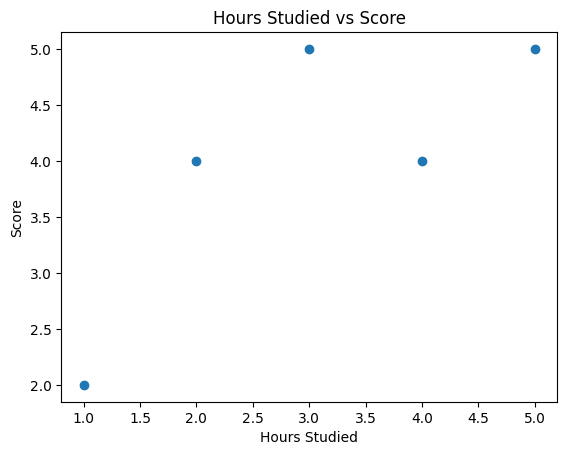

In [3]:
import matplotlib.pyplot as plt

plt.scatter(df['Hours_Studied'], df['Score'])
plt.xlabel('Hours Studied')
plt.ylabel('Score')
plt.title('Hours Studied vs Score')
plt.show()

## 3.Feature and Target Separation

In supervised machine learning we divide the dataset into:

- **Feature (X)**-> the input variable used to make predictions.
- **Target (y)** ->  the variable we want to predict.

In this example:

- **Hours Studied** is the feature.
- **Score** is the target.

The goal of the model is to learn the relationship between study hours and exam score.

In [4]:
X = df[['Hours_Studied']]
y = df['Score']

## 4. Model Training

We now train a **Linear Regression** model.

Linear regression attempts to find the best fitting straight line that represents the relationship between the feature and the target.

The mathematical form of the model is:

Score = m × Hours_Studied + b

Where:

- **m** is the slope (how much score changes per hour studied)
- **b** is the intercept (predicted score when hours studied is 0)

The model learns these parameters from the data.

In [5]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X, y)

LinearRegression()

## 5. Predictions

After training the model, we use it to predict scores based on the hours studied.

These predictions will form the **regression line**, which represents the model's estimate of the relationship between study time and score.

In [18]:
y_pred = model.predict(X)
print(y_pred)

#model.predict([[7]])

[2.8 3.4 4.  4.6 5.2]


C:\Users\hp\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([6.4])

## 6. Regression Line Visualization

The regression line represents the best fitting straight line learned by the model.

It passes through the data in a way that minimizes the difference between the **actual scores** and the **predicted scores**.

Points above or below the line indicate prediction errors.

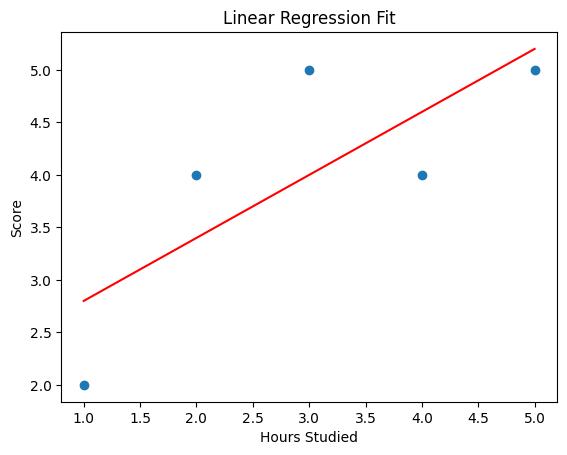

In [19]:
plt.scatter(X, y)
plt.plot(X, y_pred, color='red')
plt.xlabel("Hours Studied")
plt.ylabel("Score")
plt.title("Linear Regression Fit")
plt.show()

## 7. Model Parameters

After training the model, we can inspect the learned parameters:

- **Slope (Coefficient)**: shows how much the predicted score increases when study hours increase by one unit.
- **Intercept**: the predicted score when hours studied is zero.

These parameters define the regression equation learned by the model.

In [20]:
print("Slope:", model.coef_[0])
print("Intercept:", model.intercept_)

Slope: 0.6
Intercept: 2.2


## 8. Residual Analysis

A **residual** is the difference between the actual value and the predicted value.

Residual = Actual − Predicted

Residual plots help us understand how well the model fits the data.  
If the residuals are randomly scattered around zero, the linear model is likely appropriate.

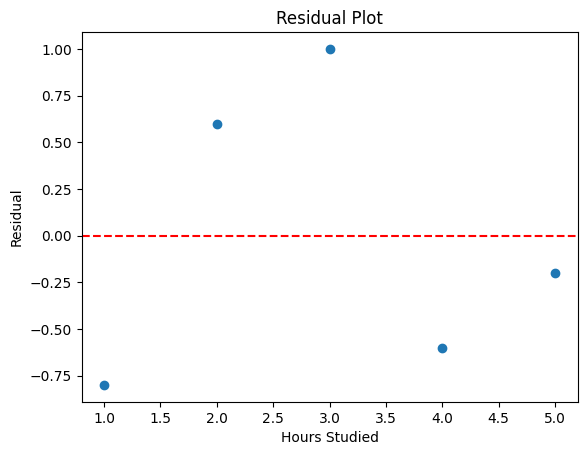

In [21]:
residuals = y - y_pred

plt.scatter(X, residuals)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Hours Studied")
plt.ylabel("Residual")
plt.title("Residual Plot")
plt.show()

## 9. Observations / Intuition

- The scatter plot shows a positive relationship between study hours and exam score.
- The regression line captures the general upward trend in the data.
- Some data points lie above or below the regression line, which represents prediction errors.
- The slope indicates how much the predicted score increases with additional study time.
- The residual plot helps visualize the distribution of prediction errors.

This experiment demonstrates how linear regression can model simple relationships between variables.

## 10. Testing Model on New Unseen Data

- The main purpose of a machine learning model is to make predictions on data that it has not seen before.

- After training the linear regression model on the dataset, we can test it by providing new input values.

- For example, we can estimate the expected exam score for a student who studies for a certain number of hours.

- This demonstrates how the trained model can generalize its learned relationship to new data points.

In [22]:
hours = [[7]]

predicted_score = model.predict(hours)

print("Hours Studied:", hours[0][0])
print("Predicted Score:", predicted_score[0])

Hours Studied: 7
Predicted Score: 6.4


C:\Users\hp\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


## 11. Plotting the predicted point.

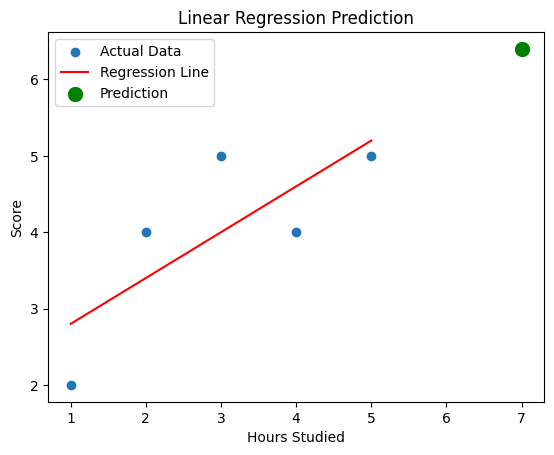

In [23]:
plt.scatter(X, y, label="Actual Data")
plt.plot(X, y_pred, color='red', label="Regression Line")

plt.scatter(hours, predicted_score, color='green', s=100, label="Prediction")

plt.xlabel("Hours Studied")
plt.ylabel("Score")
plt.title("Linear Regression Prediction")
plt.legend()

plt.show()